In [1]:
!pip install -q transformers datasets peft accelerate evaluate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

path = "/content/drive/MyDrive/mt5_results/val_predictions.csv"

df = pd.read_csv(path)

# Only what you need
refs = df["reference"].astype(str).tolist()
preds = df["prediction"].astype(str).tolist()

print("Loaded samples:", len(refs))

Loaded samples: 5180


In [9]:
decoded_preds=preds
decoded_labels=refs


In [4]:
!pip install python-Levenshtein seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 61.1 MB/s eta 0:00:00


In [5]:
import re

def capitalization_error(pred, ref):
    # compare lowercase versions
    if pred.lower() == ref.lower() and pred != ref:
        return True
    return False

In [6]:
def punctuation_error(pred, ref):
    pred_punc = re.sub(r"[a-zA-Z\u0B80-\u0BFF0-9\s]", "", pred)
    ref_punc  = re.sub(r"[a-zA-Z\u0B80-\u0BFF0-9\s]", "", ref)
    return pred_punc != ref_punc

In [7]:
def extract_tamil(text):
    return re.findall(r'[\u0B80-\u0BFF]+', text)

def tamil_mismatch(pred, ref):
    return extract_tamil(pred) != extract_tamil(ref)

In [8]:
def suffix_error(pred, ref):
    pred_words = pred.split()
    ref_words = ref.split()

    min_len = min(len(pred_words), len(ref_words))

    errors = 0

    for i in range(min_len):
        pw = pred_words[i]
        rw = ref_words[i]

        if len(rw) > 3:
            if pw[-3:] != rw[-3:]:
                errors += 1

    return errors > 0

In [10]:
analysis = []

for pred, ref in zip( decoded_preds, decoded_labels):
    result = {

        "prediction": pred,
        "reference": ref,
        "capitalization_error": capitalization_error(pred, ref),
        "punctuation_error": punctuation_error(pred, ref),
        "tamil_error": tamil_mismatch(pred, ref),
        "suffix_error": suffix_error(pred, ref)
    }
    analysis.append(result)

In [11]:
from collections import Counter

counter = Counter()

for a in analysis:
    if a["capitalization_error"]:
        counter["capitalization"] += 1
    if a["punctuation_error"]:
        counter["punctuation"] += 1
    if a["tamil_error"]:
        counter["tamil"] += 1
    if a["suffix_error"]:
        counter["suffix"] += 1

print(counter)

Counter({'suffix': 3441, 'tamil': 3232, 'punctuation': 1757, 'capitalization': 139})


In [12]:
total = len(analysis)

for k, v in counter.items():
    print(f"{k}: {v} ({v/total:.2%})")

punctuation: 1757 (33.92%)
tamil: 3232 (62.39%)
suffix: 3441 (66.43%)
capitalization: 139 (2.68%)


In [13]:
import Levenshtein

def get_char_pairs(pred, ref):
    ops = Levenshtein.editops(ref, pred)

    pairs = []
    i, j = 0, 0

    for op, r_pos, p_pos in ops:
        if op == 'replace':
            pairs.append((ref[r_pos], pred[p_pos]))
        elif op == 'delete':
            pairs.append((ref[r_pos], '∅'))
        elif op == 'insert':
            pairs.append(('∅', pred[p_pos]))

    return pairs

In [14]:
from collections import Counter

char_confusion = Counter()

for pred, ref in zip(decoded_preds, decoded_labels):
    pairs = get_char_pairs(pred, ref)
    char_confusion.update(pairs)

In [15]:
import pandas as pd

df_conf = pd.DataFrame(
    [(r, p, c) for (r, p), c in char_confusion.items()],
    columns=["ref_char", "pred_char", "count"]
)

pivot = df_conf.pivot_table(
    index="ref_char",
    columns="pred_char",
    values="count",
    fill_value=0
)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2949 (\N{TAMIL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2950 (\N{TAMIL LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2951 (\N{TAMIL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2953 (\N{TAMIL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPytho

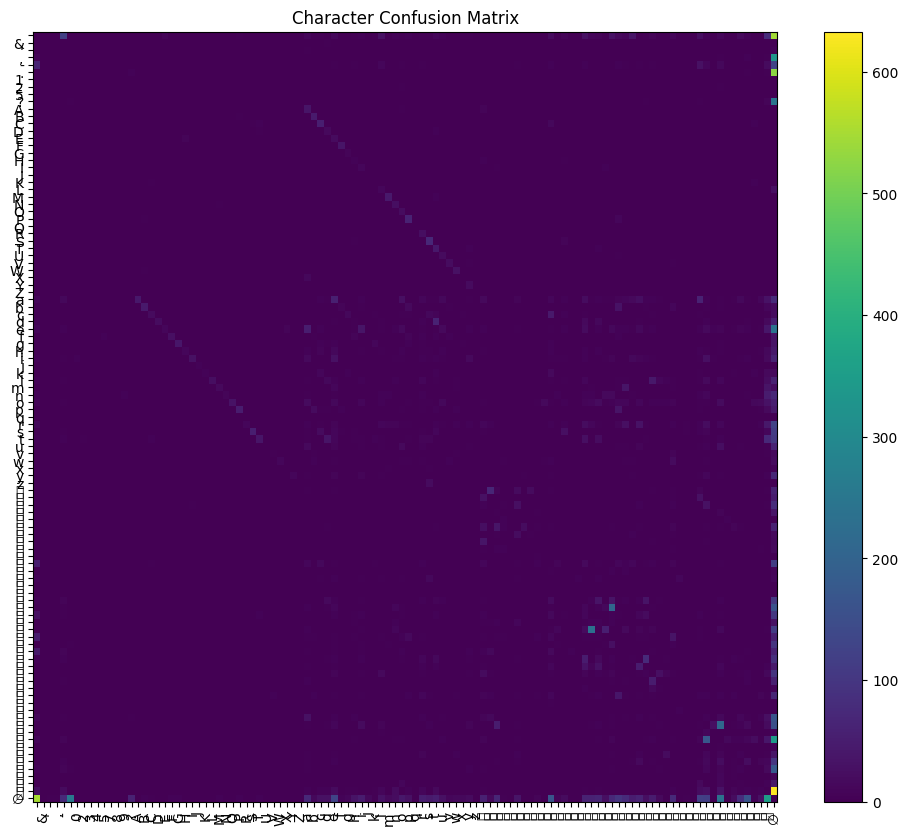

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(pivot, aspect='auto')
plt.colorbar()
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Character Confusion Matrix")
plt.show()

In [17]:
def get_suffix(word, k=3):
    return word[-k:] if len(word) >= k else word

suffix_confusion = Counter()

for pred, ref in zip(decoded_preds, decoded_labels):
    pw = pred.split()
    rw = ref.split()

    for p, r in zip(pw, rw):
        suffix_confusion[(get_suffix(r), get_suffix(p))] += 1

In [18]:
df_suffix = pd.DataFrame(
    [(r, p, c) for (r, p), c in suffix_confusion.items()],
    columns=["ref_suffix", "pred_suffix", "count"]
)

pivot_suffix = df_suffix.pivot_table(
    index="ref_suffix",
    columns="pred_suffix",
    values="count",
    fill_value=0
)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2949 (\N{TAMIL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2950 (\N{TAMIL LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2985 (\N{TAMIL LETTER NNNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2994 (\N{TAMIL LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IP

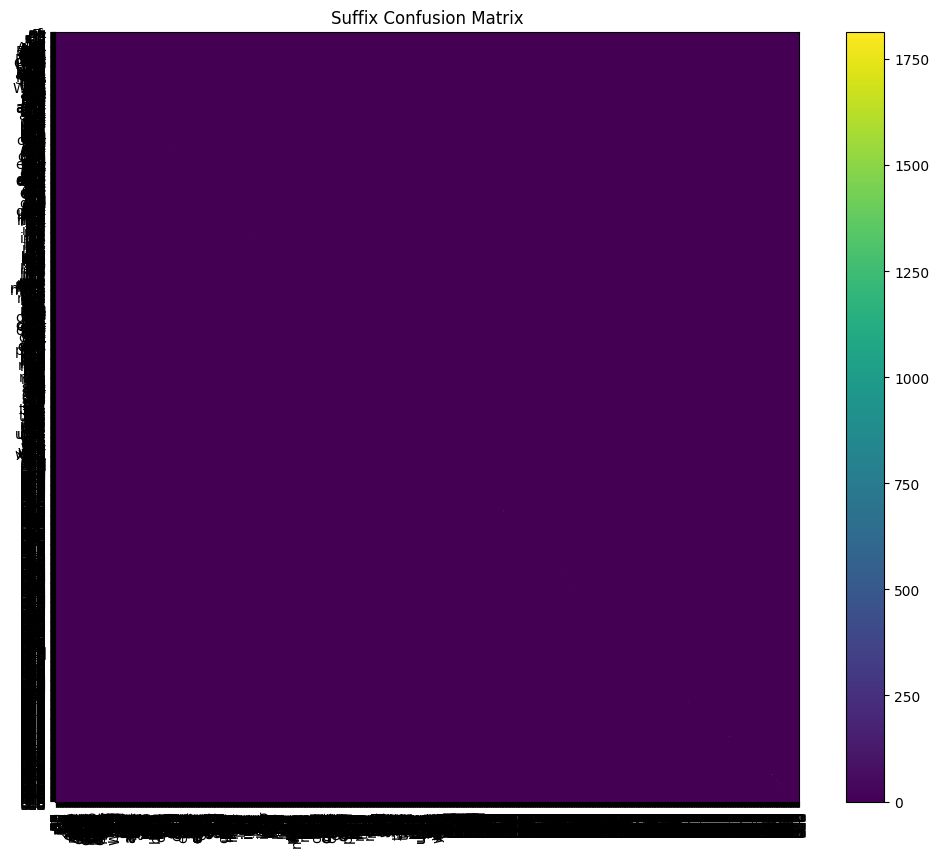

In [19]:
plt.figure(figsize=(12, 10))
plt.imshow(pivot_suffix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(pivot_suffix.columns)), pivot_suffix.columns, rotation=90)
plt.yticks(range(len(pivot_suffix.index)), pivot_suffix.index)
plt.title("Suffix Confusion Matrix")
plt.show()

In [20]:
import Levenshtein
from collections import Counter

def get_char_pairs(pred, ref):
    ops = Levenshtein.editops(ref, pred)
    pairs = []

    for op, r_pos, p_pos in ops:
        if op == 'replace':
            pairs.append((ref[r_pos], pred[p_pos]))
        elif op == 'delete':
            pairs.append((ref[r_pos], '∅'))
        elif op == 'insert':
            pairs.append(('∅', pred[p_pos]))

    return pairs

In [21]:
char_confusion = Counter()

for pred, ref in zip(preds, refs):
    pairs = get_char_pairs(pred, ref)
    char_confusion.update(pairs)

# Convert to DataFrame
df_conf = pd.DataFrame(
    [(r, p, c) for (r, p), c in char_confusion.items()],
    columns=["ref_char", "pred_char", "count"]
)

pivot_char = df_conf.pivot_table(
    index="ref_char",
    columns="pred_char",
    values="count",
    fill_value=0
)

print("Character matrix shape:", pivot_char.shape)

Character matrix shape: (105, 110)


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2975 (\N{TAMIL LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2979 (\N{TAMIL LETTER NNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2980 (\N{TAMIL LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2985 (\N{TAMIL LETTER NNNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/sea

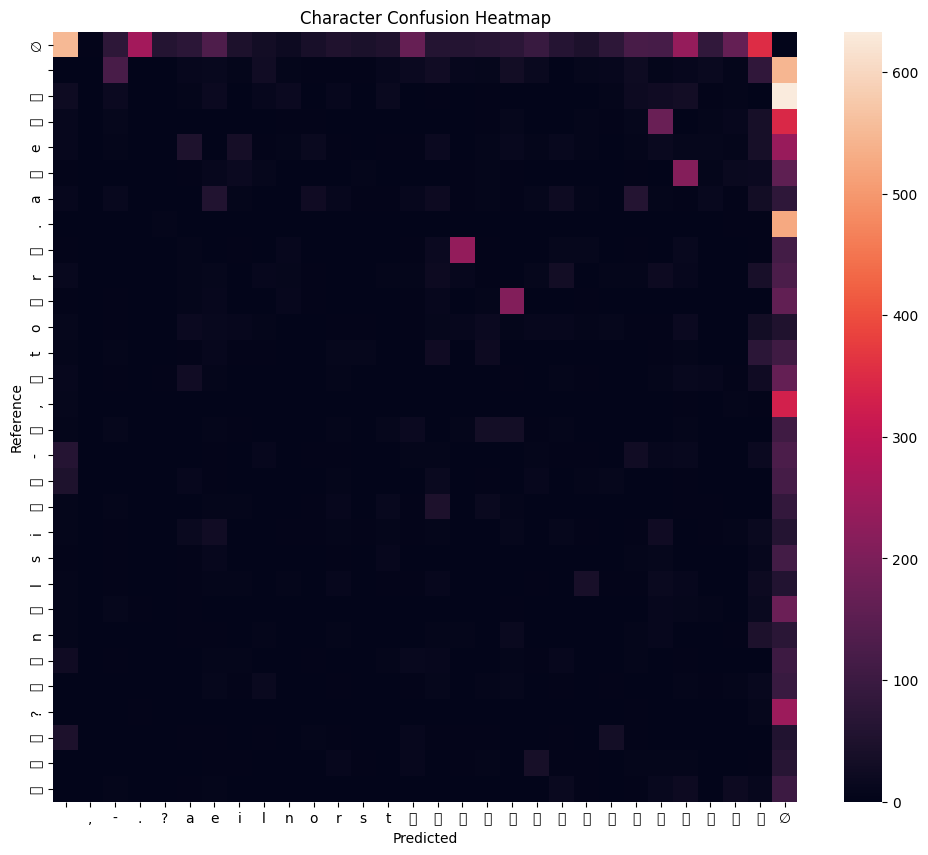

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔥 Limit to top frequent chars (avoid huge messy plot)
top_chars = df_conf.groupby("ref_char")["count"].sum().nlargest(30).index
filtered = pivot_char.loc[top_chars, pivot_char.columns.intersection(top_chars)]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered, annot=False)
plt.title("Character Confusion Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Reference")
plt.show()

In [23]:
def get_suffix(word, k=3):
    return word[-k:] if len(word) >= k else word

suffix_confusion = Counter()

for pred, ref in zip(preds, refs):
    pw = pred.split()
    rw = ref.split()

    for p, r in zip(pw, rw):
        suffix_confusion[(get_suffix(r), get_suffix(p))] += 1

df_suffix = pd.DataFrame(
    [(r, p, c) for (r, p), c in suffix_confusion.items()],
    columns=["ref_suffix", "pred_suffix", "count"]
)

pivot_suffix = df_suffix.pivot_table(
    index="ref_suffix",
    columns="pred_suffix",
    values="count",
    fill_value=0
)

print("Suffix matrix shape:", pivot_suffix.shape)

Suffix matrix shape: (1619, 1909)


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2994 (\N{TAMIL LETTER LA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2962 (\N{TAMIL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2965 (\N{TAMIL LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seabo

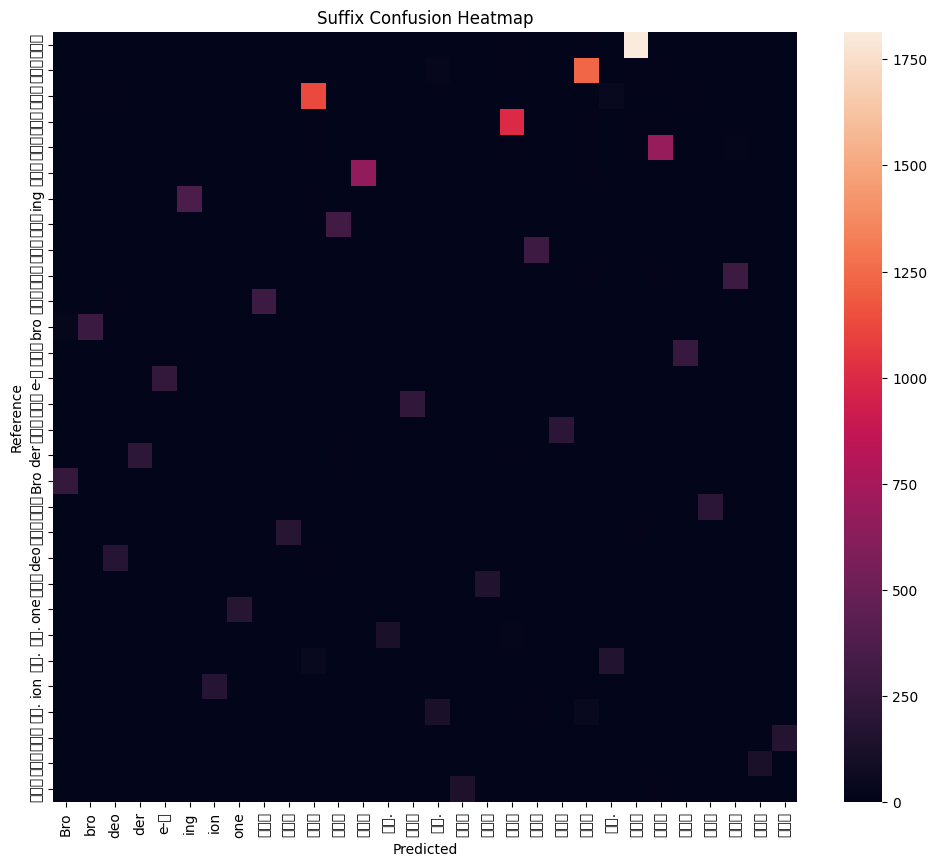

In [24]:
# 🔥 Top suffixes only
top_suffix = df_suffix.groupby("ref_suffix")["count"].sum().nlargest(30).index
filtered_suffix = pivot_suffix.loc[top_suffix, pivot_suffix.columns.intersection(top_suffix)]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_suffix, annot=False)
plt.title("Suffix Confusion Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Reference")
plt.show()